# Reagent Recommender

Demonstrate how the production model can be used as a **reagent recommender** for Buchwald–Hartwig reactions.

1. Build a reagent dictionary from the training data (catalysts, bases, solvents above min-count threshold)
2. Select a substrate pair
3. Predict all reagent combinations for that substrate pair
4. Visualize the prediction distribution and recommend an X-well HTE plate

In [1]:
import os
import pickle
import sys
import types
import warnings
from itertools import product as iter_product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch

from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from IPython.display import display, SVG

from utils.drfp_cluster import compute_drfp

# Pandas 2.x compatibility for older pickles
if "pandas.core.indexes.numeric" not in sys.modules:
    numeric_module = types.ModuleType("pandas.core.indexes.numeric")
    sys.modules["pandas.core.indexes.numeric"] = numeric_module
else:
    numeric_module = sys.modules["pandas.core.indexes.numeric"]
try:
    from pandas.core.indexes.base import Index as _PandasIndex
    for _cls_name in ("NumericIndex", "Int64Index", "UInt64Index", "Float64Index"):
        if not hasattr(numeric_module, _cls_name):
            setattr(numeric_module, _cls_name, _PandasIndex)
except Exception:
    pass

warnings.filterwarnings("ignore")
os.makedirs("visuals", exist_ok=True)

## 1. Load Production Model & Training Data

In [2]:
# Load production model
with open("model/production_model_split_RF_2026-2-24.pkl", "rb") as f:
    artifact = pickle.load(f)

model = artifact["model"]
scaler = artifact["scaler"]

# Load training data (for reagent QM descriptor lookup)
with open("data/2026-02-18_df_HTE_BH_QM_10iter_9-3clustertest.pkl", "rb") as f:
    df_train = pickle.load(f)

print(f"\nTraining data: {len(df_train)} reactions")


Training data: 23693 reactions


## 2. Build Reagent Dictionary

Extract catalysts, bases, and solvents appearing > 200 times in the training data.  
Each entry stores the reagent role, name, SMILES, and physicochemical descriptors (QM) used by the model.

In [3]:
# --- Configuration ---
MIN_COUNT_CATALYST = 400
MIN_COUNT_BASE = 1000
MIN_COUNT_SOLVENT = 2000
N_TOP = 10          # number of top predictions to display
N_PLATE_WELLS = 8   # number of wells in the recommended HTE plate

def build_reagent_dict(df, role, name_col, smiles_col, qm_start, qm_end, min_count):
    """Build reagent entries for one role (catalyst/base/solvent)."""
    counts = df.groupby([name_col, smiles_col]).size().reset_index(name="Count")
    counts = counts[counts["Count"] >= min_count].sort_values("Count", ascending=False)
    
    entries = []
    for _, row in counts.iterrows():
        name, smi = row[name_col], row[smiles_col]
        # Look up QM descriptors from the first matching row
        qm = np.array(df[df[smiles_col] == smi]["QM"].iloc[0])
        entries.append({
            "Role": role, "Name": name, "SMILES": smi,
            "QM": list(qm[qm_start:qm_end]), "Count": int(row["Count"]),
        })
    return entries

# Exclude "empty" catalyst placeholder
df_no_empty = df_train[df_train["Catalyst Name"] != "empty"]

reagent_list = []
reagent_list += build_reagent_dict(df_no_empty, "Catalyst", "Catalyst Name", "Catalyst SMILES", 14, 21, MIN_COUNT_CATALYST)
reagent_list += build_reagent_dict(df_train, "Base", "Base Name", "Base SMILES", 21, 28, MIN_COUNT_BASE)
reagent_list += build_reagent_dict(df_train, "Solvent", "Solvent Name", "Solvent SMILES", 28, 35, MIN_COUNT_SOLVENT)

reagent_df = pd.DataFrame(reagent_list)

# Save to data folder
reagent_df.to_csv("data/reagent_dictionary.csv", index=False)
print(f"Reagent dictionary: {len(reagent_df)} entries saved to data/reagent_dictionary.csv")
print(reagent_df.groupby("Role").size().to_string())
reagent_df.head()

Reagent dictionary: 23 entries saved to data/reagent_dictionary.csv
Role
Base         7
Catalyst    11
Solvent      5


,Role,Name,SMILES,QM,Count
0,Catalyst,cphos-pd-g4,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCC...,"[0.046149809308538035, -0.37709692131526823, 2...",4204
1,Catalyst,ruphos-pd-g4,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1[P+](C1CCCCC1)(...,"[0.0, 0.0, 217.6934999999993, 66.2700000000000...",1401
2,Catalyst,p(tbu)3-pd-g4,C[NH+]1c2ccccc2-c2ccccc2[Pd-2]1(OS(C)(=O)=O)[P...,"[0.0, 0.0, 140.16649999999993, 47.81, 5.426900...",1332
3,Catalyst,xphos-pd-g4,CC(C)c1cc(C(C)C)c(-c2ccccc2[P+](C2CCCCC2)(C2CC...,"[0.0, 0.0, 228.43249999999918, 47.81, 11.05949...",1307
4,Catalyst,brettphos-pd-g4,COc1ccc(OC)c([P+](C2CCCCC2)(C2CCCCC2)[Pd-2]2(O...,"[0.0, 0.0, 241.53649999999902, 66.270000000000...",1163


## 3. Select a Previously Failed Reaction

Load the experimentally validated results and select a substrate pair that was previously unsuccessful and subsequently salvaged with model-recommended reagents.

In [4]:
df_results = pd.read_csv("data/BH_Manu_NewConditions_20250310_result.csv")
df_results.rename(columns={"Unnamed: 16": "Yield"}, inplace=True)

experiment = 2

# Select T-x: 24 prior failures
rxn = df_results[df_results["Transformation ID"] == f"T-{experiment}"].iloc[0]
aryl_smi = rxn["Aryl Halide SMILES"]
amine_smi = rxn["Amine SMILES"]
product_smi = rxn["Product SMILES"]

print(f"Substrate pair (T-{experiment})")
print(f"  Aryl halide: {aryl_smi}")
print(f"  Amine:       {amine_smi}")
print(f"  Product:     {product_smi}")
print(f"  Prior failures: {rxn['Prior Fail Count']}")

# Show experimental results for this transformation
tx = df_results[df_results["Transformation ID"] == f"T-{experiment}"][
    ["Catalyst Name", "Base Name", "Solvent Name", "pred_probability", "Yield"]
].reset_index(drop=True)
print(f"\nExperimental results for model-recommended conditions:")
print(tx.to_string(index=False))

Substrate pair (T-2)
  Aryl halide: COC(=O)C1=CC=C(C=C1)Br
  Amine:       C1=C(C=C(C=C1F)F)CN
  Product:     COC(=O)C1=CC=C(C=C1)NCC2=CC(=CC(=C2)F)F
  Prior failures: 2

Experimental results for model-recommended conditions:
  Catalyst Name Base Name Solvent Name  pred_probability  Yield
    xphos-pd-g4      P2Et       t-AmOH             0.935    0.0
    xphos-pd-g4      P2Et          DMA             0.930    0.0
brettphos-pd-g4      P2Et       t-AmOH             0.920   15.0
   ruphos-pd-g4      P2Et       t-AmOH             0.915   33.0
    xphos-pd-g4      P2Et      Toluene             0.905    1.0
   ruphos-pd-g4      P2Et         DMSO             0.905   37.0


In [ ]:
# Draw the target reaction: Aryl Halide + Amine → Product
from rdkit.Chem.Draw import rdMolDraw2D

rxn_smiles = f"{aryl_smi}.{amine_smi}>>{product_smi}"
rxn = AllChem.ReactionFromSmarts(rxn_smiles, useSmiles=True)

d = rdMolDraw2D.MolDraw2DSVG(1000, 350)
d.DrawReaction(rxn)
d.FinishDrawing()
svg_text = d.GetDrawingText()

svg_path = f"visuals/reaction_T{experiment}.svg"
with open(svg_path, "w") as f:
    f.write(svg_text)

print(f"Saved to {svg_path}")
display(SVG(svg_text))

## 4. Predict All Reagent Combinations

Compute the substrate fingerprint (DRFP_subst_prod), then generate all catalyst × base × solvent combinations from the reagent dictionary and predict the probability of success.

In [6]:
# Compute DRFP_subst_prod: XOR(product_fp, aryl_fp | amine_fp)
rxn_smi = f"{aryl_smi}.{amine_smi}>>{product_smi}"
drfp_subst_prod = compute_drfp(rxn_smi, radius=3, nBits=2048).astype(np.float64)
print(f"DRFP_subst_prod computed: {drfp_subst_prod.shape}, sum={drfp_subst_prod.sum():.0f} bits set")

# Separate reagents by role
catalysts = reagent_df[reagent_df["Role"] == "Catalyst"].reset_index(drop=True)
bases = reagent_df[reagent_df["Role"] == "Base"].reset_index(drop=True)
solvents = reagent_df[reagent_df["Role"] == "Solvent"].reset_index(drop=True)

# Generate all combinations and build feature matrix
rows = []
features = []
for ci, bi, si in iter_product(range(len(catalysts)), range(len(bases)), range(len(solvents))):
    cat_qm = np.array(catalysts.loc[ci, "QM"])
    bas_qm = np.array(bases.loc[bi, "QM"])
    sol_qm = np.array(solvents.loc[si, "QM"])
    reagent_qm = np.concatenate([cat_qm, bas_qm, sol_qm])
    feat = np.concatenate([drfp_subst_prod, reagent_qm])
    features.append(feat)
    rows.append({
        "Catalyst": catalysts.loc[ci, "Name"],
        "Base": bases.loc[bi, "Name"],
        "Solvent": solvents.loc[si, "Name"],
    })

X = np.vstack(features)
X_scaled = scaler.transform(X)

# Predict
probas = model.predict_proba(X_scaled)[:, 1]

df_pred = pd.DataFrame(rows)
df_pred["Probability"] = probas
df_pred = df_pred.sort_values("Probability", ascending=False).reset_index(drop=True)

print(f"\n{len(df_pred)} reagent combinations scored")
print(f"Probability range: [{probas.min():.3f}, {probas.max():.3f}]")
print(f"Mean: {probas.mean():.3f}, Median: {np.median(probas):.3f}")

DRFP_subst_prod computed: (2048,), sum=30 bits set

385 reagent combinations scored
Probability range: [0.332, 0.821]
Mean: 0.577, Median: 0.590


## 5. Prediction Distribution

Histogram of predicted success probabilities across all reagent combinations. Colors indicate predicted outcome: red (low probability) → white (borderline) → green (high probability).

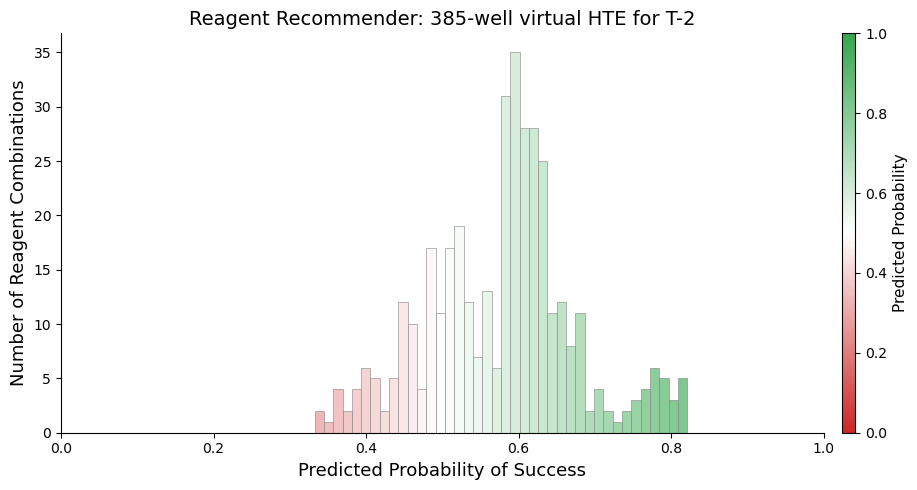

In [7]:
# Custom red → white → green colormap
rwg_cmap = mcolors.LinearSegmentedColormap.from_list(
    "rwg", [(0.8, 0.15, 0.15), (1.0, 1.0, 1.0), (0.2, 0.65, 0.3)], N=256
)

fig, ax = plt.subplots(figsize=(10, 5))
n_bins = 40
counts, bin_edges, patches = ax.hist(df_pred["Probability"], bins=n_bins, edgecolor="grey", linewidth=0.4)

# Color each bar by its bin center
for patch, left, right in zip(patches, bin_edges[:-1], bin_edges[1:]):
    center = (left + right) / 2
    patch.set_facecolor(rwg_cmap(center))

ax.set_xlabel("Predicted Probability of Success", fontsize=13)
ax.set_ylabel("Number of Reagent Combinations", fontsize=13)
ax.set_title(f"Reagent Recommender: {len(df_pred)}-well virtual HTE for T-{experiment}", fontsize=14)
ax.set_xlim(0, 1)
ax.spines[["top", "right"]].set_visible(False)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=rwg_cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30)
cbar.set_label("Predicted Probability", fontsize=11)

plt.tight_layout()
fig.savefig(f"visuals/histogram_T{experiment}.svg", bbox_inches="tight")
plt.show()

## 6. Top Predicted Reagent Combinations

In [8]:
top_n = df_pred.head(N_TOP).copy()
top_n.index = range(1, N_TOP + 1)
top_n.index.name = "Rank"
top_n["Probability"] = top_n["Probability"].map("{:.3f}".format)
top_n

,Catalyst,Base,Solvent,Probability
Rank,,,,
1,ruphos-pd-g4,P2Et,t-AmOH,0.821
2,xphos-pd-g4,P2Et,DMA,0.820
3,xphos-pd-g4,P2Et,t-AmOH,0.819
4,brettphos-pd-g4,P2Et,t-AmOH,0.815
5,p(tbu)3-pd-g4,P2Et,DMSO,0.813
6,brettphos-pd-g4,P2Et,DMA,0.808
7,ruphos-pd-g4,P2Et,DMA,0.806
8,gphos-pd-g4,P2Et,t-AmOH,0.805
9,p(tbu)3-pd-g4,P2Et,t-AmOH,0.796


## 7. Recommended HTE Plate

Select the top reagent combinations and present them as an HTE plate layout.

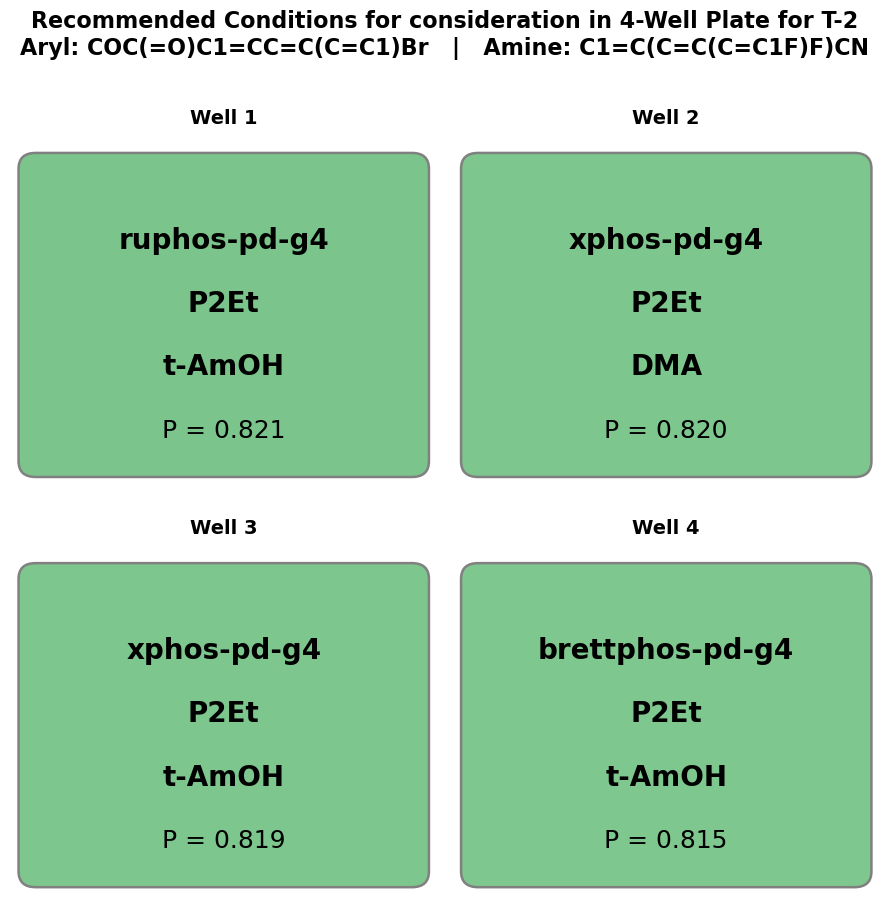

In [47]:
# Number of wells to display (can be less than N_PLATE_WELLS)
N_PLATE_DISPLAY = 4

plate = df_pred.head(N_PLATE_DISPLAY).reset_index(drop=True)

# Compute grid layout: prefer roughly square grids
if N_PLATE_DISPLAY <= 4:
    n_cols = 2
else:
    n_cols = min(4, N_PLATE_DISPLAY)
n_rows = int(np.ceil(N_PLATE_DISPLAY / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows))
axes = np.atleast_2d(axes)

fig.suptitle(
    f"Recommended Conditions for consideration in {N_PLATE_DISPLAY}-Well Plate for T-{experiment}\n"
    f"Aryl: {aryl_smi}   |   Amine: {amine_smi}",
    fontsize=16, fontweight="bold", y=1.01
)

for idx, ax in enumerate(axes.flat):
    if idx >= N_PLATE_DISPLAY:
        ax.axis("off")
        continue

    row = plate.iloc[idx]
    prob = row["Probability"]
    color = rwg_cmap(prob)

    # Draw well — box from y=0.08 to y=0.82
    well = FancyBboxPatch(
        (0.06, 0.08), 0.88, 0.74,
        boxstyle="round,pad=0.04", facecolor=color,
        edgecolor="grey", linewidth=1.8, transform=ax.transAxes
    )
    ax.add_patch(well)

    # Well label — clearly above the box
    ax.text(0.5, 0.95, f"Well {idx + 1}", transform=ax.transAxes,
            ha="center", va="center", fontsize=14, fontweight="bold")

    fs = 20
    
    # Reagent info — inside the box, large bold text
    ax.text(0.5, 0.64, row["Catalyst"], transform=ax.transAxes,
            ha="center", va="center", fontsize=fs, fontweight="bold")
    ax.text(0.5, 0.48, row["Base"], transform=ax.transAxes,
            ha="center", va="center", fontsize=fs, fontweight="bold")
    ax.text(0.5, 0.32, row["Solvent"], transform=ax.transAxes,
            ha="center", va="center", fontsize=fs, fontweight="bold")

    # Probability — inside box near bottom
    ax.text(0.5, 0.16, f"P = {prob:.3f}", transform=ax.transAxes,
            ha="center", va="center", fontsize=18)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

plt.tight_layout()
fig.savefig(f"visuals/plate_T{experiment}.svg", bbox_inches="tight")
plt.show()